In [1]:
import pandas as pd
import kit as kit
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
df_default = pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv",
                header = 0, index_col =0, na_values = -99)


cols = ["Hi 20", "Lo 20"]
df = df_default[cols]
df.head()

,Hi 20,Lo 20
192607,3.33,-0.57
192608,2.33,3.84
192609,-0.09,-0.48
192610,-2.95,-3.29
192611,3.16,-0.55


In [4]:
#Q1: Expected return of Lo20 over period of time
n_months = df.shape[0]
return_per_month = (1+df).prod()**(1/n_months) - 1
annual_return = (1+return_per_month)**12 -1
annual_return

/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/numpy/core/_methods.py:53: RuntimeWarning: overflow encountered in reduce
  return umr_prod(a, axis, dtype, out, keepdims, initial, where)


Hi 20   -1.0
Lo 20    inf
dtype: float64

<Axes: >

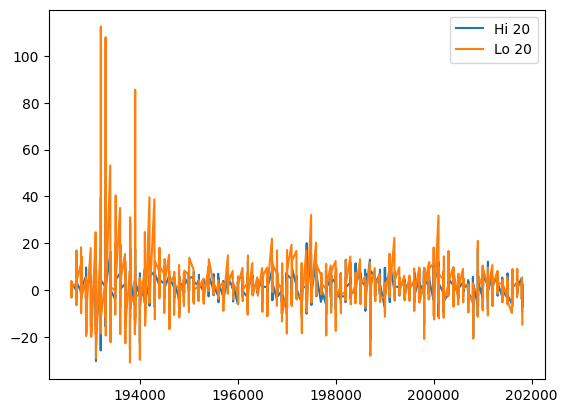

In [5]:
df.plot.line()

In [6]:
# Q2: Annual volatility
annualized_vol = df.std()*np.sqrt(12)
annualized_vol 

Hi 20    19.511604
Lo 20    33.670128
dtype: float64

In [7]:
# Format datetime
df.index = pd.to_datetime(df.index, format="%Y%m")
df.index

DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', length=1110, freq=None)

In [8]:
#Q5: Annual return over period 1999-2015
df_period = df.loc["1999-01-01":"2015-12-31"].copy()/100

In [9]:
df_period
kit.annual_return_per_month(df_period)

Hi 20    0.062865
Lo 20    0.114426
dtype: float64

In [11]:
#Q6: Calculate the annual volatility
kit.annual_volatility_by_month(df_period)

Hi 20    0.172713
Lo 20    0.228894
dtype: float64

In [19]:
#Q10: Maximum drawdown low cap
kit.drawdown(df_period['Lo 20'])['Drawdown'].idxmin()

Timestamp('2009-02-01 00:00:00')

In [21]:
#Q12: Maximum drawdown large cap
kit.drawdown(df_period['Hi 20'])['Drawdown'].idxmin()

Timestamp('2009-02-01 00:00:00')

In [28]:
#Q13:  highest semideviation
rets = kit.get_hfi_returns()
kit.semideviation(rets).idxmax()

/Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/9. Introduction to Portfolio Construction/kit.py:28: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  hfi = pd.read_csv("data/edhec-hedgefundindices.csv",


'Emerging Markets'

In [29]:
rets.head()

,Convertible Arbitrage,CTA Global,Distressed Securities,Emerging Markets,Equity Market Neutral,Event Driven,Fixed Income Arbitrage,Global Macro,Long/Short Equity,Merger Arbitrage,Relative Value,Short Selling,Funds Of Funds
date,,,,,,,,,,,,,
1997-01,0.0119,0.0393,0.0178,0.0791,0.0189,0.0213,0.0191,0.0573,0.0281,0.0150,0.0180,-0.0166,0.0317
1997-02,0.0123,0.0298,0.0122,0.0525,0.0101,0.0084,0.0122,0.0175,-0.0006,0.0034,0.0118,0.0426,0.0106
1997-03,0.0078,-0.0021,-0.0012,-0.0120,0.0016,-0.0023,0.0109,-0.0119,-0.0084,0.0060,0.0010,0.0778,-0.0077
1997-04,0.0086,-0.0170,0.0030,0.0119,0.0119,-0.0005,0.0130,0.0172,0.0084,-0.0001,0.0122,-0.0129,0.0009
1997-05,0.0156,-0.0015,0.0233,0.0315,0.0189,0.0346,0.0118,0.0108,0.0394,0.0197,0.0173,-0.0737,0.0275


In [48]:
df_after_2009 = rets[rets.index.year >= 2009] 
kit.semideviation(df_after_2009).idxmin()

'Fixed Income Arbitrage'

In [50]:
kit.skewness(df_after_2009).idxmin()

'Equity Market Neutral'

In [53]:
kit.kurtosis(df_after_2009).idxmax()

'Convertible Arbitrage'